## **SOW trajectory proximity graph with retention tier projection**

### *Clinical Trial CTN-0051: Extended-Release Naltrexone vs. Buprenorphine for Opioid Treatment*

---

This notebook builds a **proximity graph** on the full SOW (Subjective Opioid Withdrawal Scale) trajectory matrix — patients × 126 features (14 symptoms × 9 scheduled weeks, LOCF-imputed). The pipeline mirrors `proximity_graph.ipynb`:

1. Load `sow_trajectories.csv`, `pre-trial.csv` (detox_los), `retention_tier.csv`, and `features_w8.csv`
2. Compute pairwise distances between patients in the 126-dim SOW trajectory space
3. Define an open cover on **detox_los** (same filter function as the baseline graph) — overlapping intervals
4. Build an ε-neighbourhood graph: connect patients $i$ and $j$ if $d(i,j) \leq \varepsilon$ **and** they share ≥1 cover set (Mapper condition)
5. Project (colour) nodes by `retention_tier`
6. Annotate nodes with week-8 landmark features: `had_relapse_by_w8`, `engagement_onset_w8`, `attendance_density_w8`
7. Lay out and display interactively with **Bokeh**

**Tunable parameters** (adjust in Section 2):
- `EPSILON` — neighbourhood radius in standardised trajectory space
- `METRIC` / `MINKOWSKI_P` — distance metric
- `COVER` — overlapping intervals on detox_los
- `LAYOUT` — graph layout algorithm

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import networkx as nx

from bokeh.plotting import figure, show, output_notebook
from bokeh.models import (
    ColumnDataSource, HoverTool, ColorBar, LinearColorMapper,
    MultiLine, Circle, Legend, LegendItem
)
from bokeh.io import push_notebook

import matplotlib.pyplot as plt
import seaborn as sns

output_notebook()
print("Imports OK")

Loading BokehJS ...

Imports OK


## 1. Load data

In [ ]:
# ── Load all sources ──────────────────────────────────────────────────────────
sow       = pd.read_csv("../data/clean-data/sow_trajectories.csv")
pre_trial = pd.read_csv("../data/clean-data/pre-trial.csv")
target    = pd.read_csv("../data/clean-data/retention_tier.csv")
w8        = pd.read_csv("../data/clean-data/features_w8.csv")

# Join on PATID — inner join keeps patients present in every source
df = (
    sow
    .merge(pre_trial[['PATID', 'detox_los']], on='PATID', how='inner')
    .merge(target[['PATID', 'retention_tier']], on='PATID', how='inner')
    .merge(w8, on='PATID', how='inner')
)

print(f"Patients after join  : {len(df)}")
print(f"SOW features         : {sow.shape[1] - 1}  (14 symptoms × 9 scheduled weeks, LOCF)")
print(f"\nRetention tier distribution:")
print(df['retention_tier'].value_counts().sort_index().to_string())
print(f"\nWeek-8 landmark features distribution:")
print(f"  had_relapse_by_w8      : {df['had_relapse_by_w8'].value_counts().sort_index().to_dict()}")
print(f"  engagement_onset_w8    : {df['engagement_onset_w8'].value_counts().sort_index().to_dict()}  (0=on_time 1=slightly_delayed 2=late 3=not_yet)")
print(f"  attendance_density_w8  : mean={df['attendance_density_w8'].mean():.3f}, std={df['attendance_density_w8'].std():.3f}")
print(f"\nDetox LOS distribution (cover filter function):")
print(df['detox_los'].describe().round(2).to_string())

In [3]:
# ── Define feature matrix (SOW trajectory columns only) ───────────────────────
feat_cols = [c for c in sow.columns if c != 'PATID']

X_raw = df[feat_cols].values
tiers = df['retention_tier'].values
los   = df['detox_los'].values      # filter function for the cover

print(f"Feature matrix shape : {X_raw.shape}")
print(f"Missing values       : {np.isnan(X_raw).sum()}")
print(f"Value range          : [{X_raw.min():.1f}, {X_raw.max():.1f}]")

Feature matrix shape : (513, 126)
Missing values       : 0
Value range          : [0.0, 4.0]


## 2. Parameters — tune here

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# TUNABLE PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

EPSILON     = 8      # neighbourhood radius in standardised trajectory space
                     # lower → sparser graph  |  higher → denser graph
                     # ε=6 → ~27.8% density (matches baseline proximity graph)
                     # ε=5 → ~19%  |  ε=7 → ~35%  |  ε=8 → ~41%

METRIC      = 'euclidean'
MINKOWSKI_P = 3      # p=1 Manhattan, p=2 Euclidean, p>2 superelliptic

LAYOUT      = 'spring'   # 'spring' | 'spectral' | 'pca'

# ── Open cover on detox_los (same filter function as proximity_graph.ipynb) ───
# Overlapping intervals — patients in the overlap zone belong to two sets,
# creating cross-set edges that act as the Mapper "bridge" between groups.
#
#   detox_los distribution (subset with SOW data):
#   min=1, p25≈5, p50=6, p75=9, max=40
#
COVER = [
    (0,  4),   # set 0 — very short stay  (0–3 days)
    (3,  7),   # set 1 — short stay       (overlaps set 0 on [3, 4))
    (6,  10),  # set 2 — moderate stay    (overlaps set 1 on [6, 7))
    (10, 40),  # set 3 — long stay        (overlaps set 2 on [10,10) — single point)
]
COVER_LABELS = ['0–4 days', '3–7 days', '6–10 days', '10+ days']

metric_str = f"{METRIC}(p={MINKOWSKI_P})" if METRIC == 'minkowski' else METRIC
print(f"ε={EPSILON}  |  metric={metric_str}  |  layout={LAYOUT}")
print(f"\nCover sets (detox_los — days in detox):")
for i, ((lo, hi), lbl) in enumerate(zip(COVER, COVER_LABELS)):
    print(f"  Set {i}: [{lo}, {hi})  — {lbl}")
print(f"\nDetox LOS distribution (for reference):")
print(df['detox_los'].describe().round(2).to_string())

ε=8  |  metric=euclidean  |  layout=spring

Cover sets (detox_los — days in detox):
  Set 0: [0, 4)  — 0–4 days
  Set 1: [3, 7)  — 3–7 days
  Set 2: [6, 10)  — 6–10 days
  Set 3: [10, 40)  — 10+ days

Detox LOS distribution (for reference):
count    513.00
mean       7.77
std        5.23
min        1.00
25%        5.00
50%        6.00
75%        9.00
max       40.00


In [31]:
# ── Assign cover memberships based on detox_los ───────────────────────────────
def get_memberships(los_val, cover):
    """Return set indices whose interval contains this detox_los value."""
    if np.isnan(los_val):
        return []
    return [i for i, (lo, hi) in enumerate(cover) if lo <= los_val < hi]

memberships = [get_memberships(v, COVER) for v in los]

print("Cover membership distribution:")
for i, (lo, hi) in enumerate(COVER):
    n = sum(1 for m in memberships if i in m)
    print(f"  Set {i} ({COVER_LABELS[i]:>12s}): {n:4d} patients")

print(f"\nPatients in multiple sets (overlap zone):")
for n_sets in [2, 3, 4]:
    count = sum(1 for m in memberships if len(m) == n_sets)
    print(f"  In exactly {n_sets} sets: {count}")

n_no_set = sum(1 for m in memberships if len(m) == 0)
print(f"\nPatients in no set (detox_los missing or out of range): {n_no_set}")

Cover membership distribution:
  Set 0 (    0–4 days):   63 patients
  Set 1 (    3–7 days):  247 patients
  Set 2 (   6–10 days):  219 patients
  Set 3 (    10+ days):  107 patients

Patients in multiple sets (overlap zone):
  In exactly 2 sets: 124
  In exactly 3 sets: 0
  In exactly 4 sets: 0

Patients in no set (detox_los missing or out of range): 1


## 3. Preprocess and compute pairwise distances

In [32]:
# ── Standardise features ──────────────────────────────────────────────────────
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_kwargs = {"p": MINKOWSKI_P} if METRIC == 'minkowski' else {}

print(f"Computing {metric_str} pairwise distances for {len(df)} patients...")
D = pairwise_distances(X, metric=METRIC, **dist_kwargs)
print(f"Distance matrix shape : {D.shape}")
print(f"Distance range        : [{D.min():.3f}, {D.max():.3f}]")
print(f"\nDistance percentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"  {p:3d}th percentile : {np.percentile(D[D>0], p):.3f}")

n_edges_raw = ((D <= EPSILON) & (D > 0)).sum() // 2
n_total     = len(df) * (len(df) - 1) // 2
print(f"\nWith ε={EPSILON}:")
print(f"  Edges before cover pruning : {n_edges_raw}")
print(f"  Edge density               : {n_edges_raw / n_total * 100:.1f}%")

Computing euclidean pairwise distances for 513 patients...
Distance matrix shape : (513, 513)
Distance range        : [0.000, 52.102]

Distance percentiles:
   10th percentile : 5.214
   25th percentile : 7.762
   50th percentile : 11.877
   75th percentile : 16.674
   90th percentile : 23.579

With ε=8:
  Edges before cover pruning : 34605
  Edge density               : 26.4%


## 4. Build ε-neighbourhood graph with cover-based pruning

In [ ]:
# ── Build graph with cover-based edge pruning (Mapper condition) ──────────────
# Edge rule: connect i and j iff
#   1. d(i,j) <= EPSILON             (proximity in SOW trajectory space)
#   2. memberships[i] ∩ memberships[j] ≠ ∅   (share ≥1 detox_los cover set)
#
# Node colour: retention_tier only.
# Node attributes: w8 landmark features (had_relapse, engagement_onset, attendance_density).

tier_label_map = {
    1: 'Early dropout',
    2: 'Mid dropout',
    3: 'Late dropout',
    4: 'Completed',
}

onset_label_map = {0: 'on_time', 1: 'slightly_delayed', 2: 'late', 3: 'not_yet_engaged'}

cover_colors = {
    -1: '#aaaaaa',
     0: '#d62728',   # 0–4 days  — red
     1: '#ff7f0e',   # 3–7 days  — orange
     2: '#2E5FAC',   # 6–10 days — blue
     3: '#2ca02c',   # 10+ days  — green
}

G = nx.Graph()

for i in range(len(df)):
    primary = memberships[i][0] if memberships[i] else -1
    onset_i = int(df['engagement_onset_w8'].iloc[i])
    G.add_node(
        i,
        patid             = int(df['PATID'].iloc[i]),
        memberships       = memberships[i],
        primary_set       = primary,
        in_overlap        = len(memberships[i]) > 1,
        tier              = int(tiers[i]) if not np.isnan(tiers[i]) else -1,
        tier_label        = tier_label_map.get(
                                int(tiers[i]) if not np.isnan(tiers[i]) else -1,
                                'Unknown'),
        detox_los         = float(los[i]),
        had_relapse_w8    = int(df['had_relapse_by_w8'].iloc[i]),
        onset_w8          = onset_i,
        onset_w8_label    = onset_label_map.get(onset_i, 'unknown'),
        attendance_w8     = float(df['attendance_density_w8'].iloc[i]),
    )

edges_added  = 0
edges_pruned = 0
edges_no_set = 0

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if D[i, j] <= EPSILON:
            mi = set(memberships[i])
            mj = set(memberships[j])
            if mi and mj and mi & mj:
                G.add_edge(i, j,
                           weight=float(D[i, j]),
                           shared_sets=list(mi & mj))
                edges_added += 1
            elif not mi or not mj:
                edges_no_set += 1
            else:
                edges_pruned += 1

print(f"Graph summary:")
print(f"  Nodes                : {G.number_of_nodes()}")
print(f"  Edges kept           : {G.number_of_edges()}   (share ≥1 cover set)")
print(f"  Edges pruned         : {edges_pruned}  (disjoint detox_los sets)")
print(f"  Edges skipped        : {edges_no_set}  (patient missing detox_los)")
print(f"  Connected components : {nx.number_connected_components(G)}")
print(f"  Isolated nodes       : {sum(1 for n in G.nodes if G.degree(n)==0)}")
print(f"  Overlap nodes (≥2 sets): {sum(1 for n in G.nodes if G.nodes[n]['in_overlap'])}")

print(f"\nMean degree by tier:")
for tier in sorted(tier_label_map.keys()):
    nodes_t = [n for n in G.nodes if G.nodes[n]['tier'] == tier]
    if nodes_t:
        mean_deg = np.mean([G.degree(n) for n in nodes_t])
        print(f"  Tier {tier} ({tier_label_map[tier]:<15s}): "
              f"{len(nodes_t):3d} nodes, mean degree = {mean_deg:.1f}")

## 5. Layout

In [34]:
# ── Compute node positions ────────────────────────────────────────────────────
print(f"Computing layout: {LAYOUT}...")

if LAYOUT == 'spring':
    G_weighted = G.copy()
    for u, v, data in G_weighted.edges(data=True):
        data['spring_weight'] = 1.0 / (data['weight'] + 1e-6)
    pos = nx.spring_layout(
        G_weighted, weight='spring_weight',
        k=8.0, iterations=30, seed=42
    )

elif LAYOUT == 'spectral':
    pos = nx.spectral_layout(G)

elif LAYOUT == 'pca':
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    pos = {i: (coords[i, 0], coords[i, 1]) for i in range(len(df))}
    print(f"  PCA variance explained: "
          f"{pca.explained_variance_ratio_[0]*100:.1f}% + "
          f"{pca.explained_variance_ratio_[1]*100:.1f}%")

for node, (x, y) in pos.items():
    G.nodes[node]['x'] = float(x)
    G.nodes[node]['y'] = float(y)

print(f"Layout computed for {len(pos)} nodes.")

Computing layout: spring...
Layout computed for 513 nodes.


## 6. Interactive Bokeh visualisation

In [ ]:
# ── Tier colour palette (node colouring — independent of cover) ───────────────
tier_colors = {
    -1: '#aaaaaa',
     1: '#ff7f0e',   # early dropout — orange
     2: '#ffbb78',   # mid dropout   — light orange
     3: '#98df8a',   # late dropout  — light green
     4: '#2ca02c',   # completed     — green
}

# ── Node source ───────────────────────────────────────────────────────────────
node_x            = [G.nodes[n]['x']             for n in G.nodes]
node_y            = [G.nodes[n]['y']             for n in G.nodes]
node_tier         = [G.nodes[n]['tier']          for n in G.nodes]
node_patid        = [G.nodes[n]['patid']         for n in G.nodes]
node_degree       = [G.degree(n)                 for n in G.nodes]
node_color        = [tier_colors[t]              for t in node_tier]
node_cover        = [G.nodes[n]['primary_set']   for n in G.nodes]
node_overlap      = [G.nodes[n]['in_overlap']    for n in G.nodes]
node_los          = [G.nodes[n]['detox_los']     for n in G.nodes]
node_relapse_w8   = [G.nodes[n]['had_relapse_w8']  for n in G.nodes]
node_onset_w8     = [G.nodes[n]['onset_w8_label']  for n in G.nodes]
node_attend_w8    = [G.nodes[n]['attendance_w8']   for n in G.nodes]

# SOW aggregates for tooltip
wk1_cols  = [c for c in feat_cols if 'wk01' in c]
wk24_cols = [c for c in feat_cols if 'wk24' in c]
node_sow_wk1  = [float(df[wk1_cols].iloc[n].sum())  for n in G.nodes]
node_sow_wk24 = [float(df[wk24_cols].iloc[n].sum()) for n in G.nodes]
node_sow_mean = [float(df[feat_cols].iloc[n].mean()) for n in G.nodes]

node_source = ColumnDataSource(dict(
    x             = node_x,
    y             = node_y,
    tier          = [str(t) for t in node_tier],
    patid         = node_patid,
    degree        = node_degree,
    color         = node_color,
    detox_los     = node_los,
    cover_set     = [str(c) for c in node_cover],
    in_overlap    = [str(o) for o in node_overlap],
    sow_wk1       = node_sow_wk1,
    sow_wk24      = node_sow_wk24,
    sow_mean      = node_sow_mean,
    relapse_w8    = [str(r) for r in node_relapse_w8],
    onset_w8      = node_onset_w8,
    attendance_w8 = node_attend_w8,
))

# ── Edge source ───────────────────────────────────────────────────────────────
edge_xs, edge_ys, edge_shared, edge_weight = [], [], [], []
for u, v, data in G.edges(data=True):
    edge_xs.append([G.nodes[u]['x'], G.nodes[v]['x']])
    edge_ys.append([G.nodes[u]['y'], G.nodes[v]['y']])
    edge_shared.append(len(data['shared_sets']))
    edge_weight.append(data['weight'])

edge_alpha = [0.55 if s == 1 else 0.70 for s in edge_shared]
edge_color = ['#aaaaaa' if s == 1 else '#555555' for s in edge_shared]

edge_source = ColumnDataSource(dict(
    xs     = edge_xs,
    ys     = edge_ys,
    shared = edge_shared,
    weight = edge_weight,
    alpha  = edge_alpha,
    color  = edge_color,
))

print(f"Node source: {len(node_x)} nodes")
print(f"Edge source: {len(edge_xs)} edges")

In [ ]:
# ── Build Bokeh figure ────────────────────────────────────────────────────────
TOOLS = "pan,wheel_zoom,box_zoom,reset,save"

p = figure(
    title=(
        f"SOW trajectory proximity graph  |  ε={EPSILON}  |  metric={metric_str}  |  "
        f"layout={LAYOUT}\n"
        f"{G.number_of_nodes()} patients · {G.number_of_edges()} edges  "
        f"({nx.number_connected_components(G)} connected components)  "
        f"|  cover: detox_los"
    ),
    tools=TOOLS,
    width=900, height=700,
    x_axis_label='', y_axis_label='',
    background_fill_color='#FAFAFA',
)
p.title.text_font_size  = '11pt'
p.title.text_font_style = 'normal'
p.axis.visible          = False
p.grid.visible          = False
p.outline_line_color    = '#DDDDDD'

# ── Edges ─────────────────────────────────────────────────────────────────────
p.multi_line(
    xs='xs', ys='ys',
    line_color='color',
    line_alpha='alpha',
    line_width=0.6,
    source=edge_source,
)

# ── Nodes ─────────────────────────────────────────────────────────────────────
node_source.data['size'] = [6] * len(node_x)

nodes_renderer = p.scatter(
    x='x', y='y',
    size='size',
    fill_color='color',
    fill_alpha=0.85,
    line_color='white',
    line_width=0.8,
    source=node_source,
)

# ── Hover tooltip ─────────────────────────────────────────────────────────────
node_hover = HoverTool(
    renderers=[nodes_renderer],
    tooltips=[
        ("PATID",              "@patid"),
        ("Retention tier",     "@tier"),
        ("Detox LOS",          "@detox_los{0.0} days"),
        ("Cover set",          "@cover_set"),
        ("Overlap node",       "@in_overlap"),
        ("Degree",             "@degree connections"),
        ("─── Week-8 features ───", ""),
        ("Relapse by wk8",     "@relapse_w8"),
        ("Engagement onset",   "@onset_w8"),
        ("Attendance density", "@attendance_w8{0.000}"),
        ("─── SOW scores ───",  ""),
        ("SOW wk1 total",      "@sow_wk1{0.0}"),
        ("SOW mean (all wks)", "@sow_mean{0.00}"),
        ("SOW wk24 total",     "@sow_wk24{0.0}"),
    ]
)
p.add_tools(node_hover)

# ── Legend (retention tier) ───────────────────────────────────────────────────
legend_items = []
for tier_val, label in tier_label_map.items():
    n_tier = sum(1 for t in node_tier if t == tier_val)
    if n_tier == 0:
        continue
    dummy = p.scatter(
        x=[float('nan')], y=[float('nan')],
        size=10,
        fill_color=tier_colors[tier_val],
        line_color='white', line_width=0.8,
        fill_alpha=0.85,
    )
    legend_items.append(LegendItem(
        label=f"Tier {tier_val}: {label} (n={n_tier})",
        renderers=[dummy]
    ))

legend = Legend(
    items=legend_items,
    location='top_right',
    background_fill_alpha=0.9,
    border_line_color='#CCCCCC',
    label_text_font_size='9pt',
    glyph_width=12, glyph_height=12,
    spacing=4,
)
p.add_layout(legend, 'right')

show(p)

## 7. Graph statistics by tier

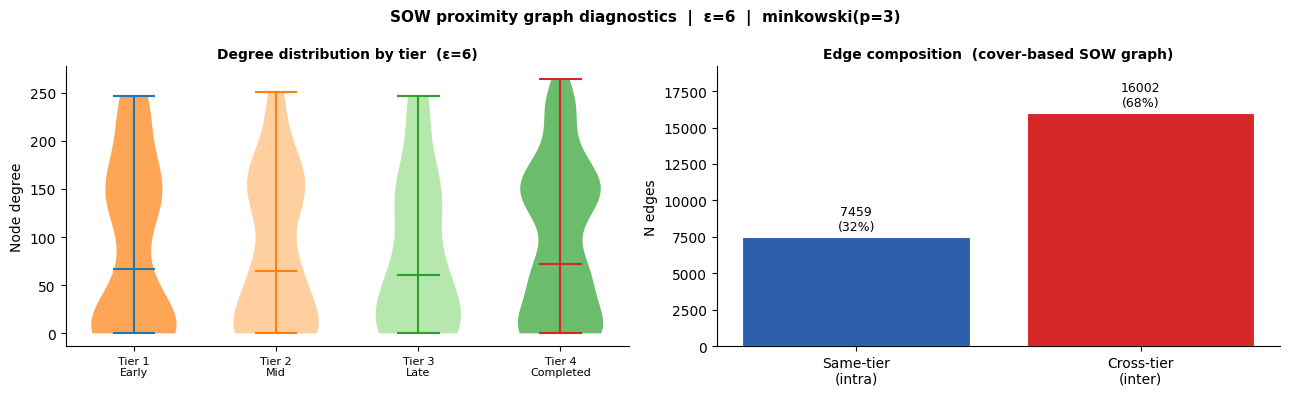

In [11]:
# ── Degree distribution by tier ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

degree_data = pd.DataFrame({
    'degree' : [G.degree(n) for n in G.nodes],
    'tier'   : [G.nodes[n]['tier'] for n in G.nodes],
})

active_tiers = sorted(degree_data['tier'].unique())
for i, tier in enumerate(active_tiers):
    vals = degree_data[degree_data['tier'] == tier]['degree']
    if len(vals) == 0:
        continue
    color = tier_colors.get(tier, '#aaaaaa')
    vp = axes[0].violinplot(vals, positions=[i], showmedians=True, widths=0.6)
    for part in vp['bodies']:
        part.set_facecolor(color)
        part.set_alpha(0.7)

axes[0].set_xticks(range(len(active_tiers)))
axes[0].set_xticklabels(
    [f"Tier {t}\n{tier_label_map.get(t,'?').split()[0]}" for t in active_tiers],
    fontsize=8
)
axes[0].set_ylabel('Node degree', fontsize=10)
axes[0].set_title(f'Degree distribution by tier  (ε={EPSILON})',
                  fontsize=10, fontweight='bold')
sns.despine(ax=axes[0])

# ── Intra- vs inter-tier edge counts ─────────────────────────────────────────
intra = sum(1 for u, v in G.edges() if G.nodes[u]['tier'] == G.nodes[v]['tier'])
inter = G.number_of_edges() - intra

axes[1].bar(
    ['Same-tier\n(intra)', 'Cross-tier\n(inter)'],
    [intra, inter],
    color=['#2E5FAC', '#d62728'], edgecolor='white', linewidth=0.8
)
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f'{intra}\n({intra/(intra+inter)*100:.0f}%)',
             f'{inter}\n({inter/(intra+inter)*100:.0f}%)'],
    fontsize=9, padding=3
)
axes[1].set_ylabel('N edges', fontsize=10)
axes[1].set_title('Edge composition  (cover-based SOW graph)',
                  fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(intra, inter) * 1.2)
sns.despine(ax=axes[1])

plt.suptitle(f'SOW proximity graph diagnostics  |  ε={EPSILON}  |  {metric_str}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('sow_proximity_graph_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

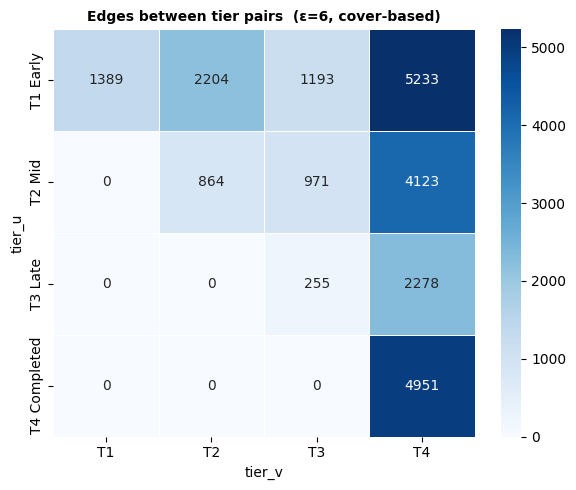


Summary:
  Total edges           : 23461
  Intra-tier edges      : 7459  (31.8%)
  Inter-tier edges      : 16002  (68.2%)
  Connected components  : 90
  Largest component     : 335 nodes
  Isolated nodes        : 87


In [12]:
# ── Cross-tier edge matrix ────────────────────────────────────────────────────
tier_pairs = pd.DataFrame(
    [(G.nodes[u]['tier'], G.nodes[v]['tier'])
     for u, v in G.edges()],
    columns=['tier_u', 'tier_v']
)
tier_pairs[['tier_u', 'tier_v']] = np.sort(
    tier_pairs[['tier_u', 'tier_v']].values, axis=1
)
edge_matrix = pd.crosstab(tier_pairs['tier_u'], tier_pairs['tier_v'])

all_tiers = sorted(tier_label_map.keys())
edge_matrix = edge_matrix.reindex(index=all_tiers, columns=all_tiers, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    edge_matrix,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=[f"T{t}" for t in all_tiers],
    yticklabels=[f"T{t} {tier_label_map[t].split()[0]}" for t in all_tiers],
    ax=ax,
)
ax.set_title(f'Edges between tier pairs  (ε={EPSILON}, cover-based)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('sow_tier_edge_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  Total edges           : {G.number_of_edges()}")
print(f"  Intra-tier edges      : {intra}  ({intra/G.number_of_edges()*100:.1f}%)")
print(f"  Inter-tier edges      : {inter}  ({inter/G.number_of_edges()*100:.1f}%)")
print(f"  Connected components  : {nx.number_connected_components(G)}")
print(f"  Largest component     : "
      f"{max(len(c) for c in nx.connected_components(G))} nodes")
print(f"  Isolated nodes        : "
      f"{sum(1 for n in G.nodes if G.degree(n)==0)}")

## 8. Cover set SOW profile

Mean SOW withdrawal trajectory per detox_los cover set — shows whether initial detox length relates to withdrawal severity over time.

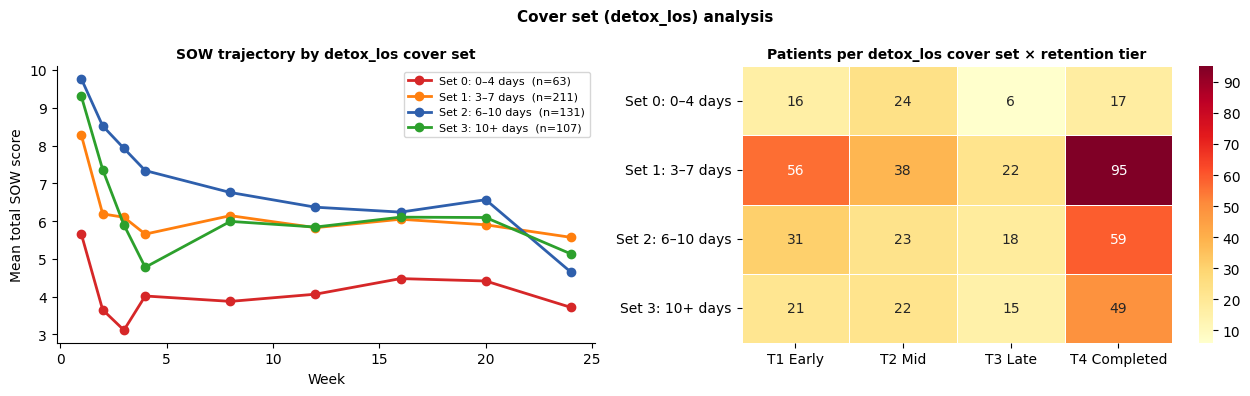

In [13]:
# ── Mean total SOW per week, by primary detox_los cover set ───────────────────
weeks = [1, 2, 3, 4, 8, 12, 16, 20, 24]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for set_idx in range(len(COVER)):
    patients_in_set = [
        i for i in G.nodes
        if G.nodes[i]['primary_set'] == set_idx
    ]
    if not patients_in_set:
        continue
    color = cover_colors[set_idx]
    label = COVER_LABELS[set_idx]

    means = []
    for wk in weeks:
        wk_cols = [c for c in feat_cols if f'_wk{wk:02d}' in c]
        vals    = df[wk_cols].iloc[patients_in_set].sum(axis=1)
        means.append(vals.mean())

    axes[0].plot(weeks, means, marker='o',
                 label=f"Set {set_idx}: {label}  (n={len(patients_in_set)})",
                 color=color, linewidth=2)

axes[0].set_xlabel('Week', fontsize=10)
axes[0].set_ylabel('Mean total SOW score', fontsize=10)
axes[0].set_title('SOW trajectory by detox_los cover set', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

# ── Cover set × tier heatmap ──────────────────────────────────────────────────
all_tiers = sorted(tier_label_map.keys())
cover_tier_mat = np.zeros((len(COVER), len(all_tiers)), dtype=int)
for i in G.nodes:
    pset = G.nodes[i]['primary_set']
    tier = G.nodes[i]['tier']
    if pset >= 0 and tier in all_tiers:
        cover_tier_mat[pset, all_tiers.index(tier)] += 1

sns.heatmap(
    cover_tier_mat,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    xticklabels=[f"T{t} {tier_label_map[t].split()[0]}" for t in all_tiers],
    yticklabels=[f"Set {i}: {COVER_LABELS[i]}" for i in range(len(COVER))],
    ax=axes[1],
)
axes[1].set_title('Patients per detox_los cover set × retention tier',
                  fontsize=10, fontweight='bold')
plt.suptitle('Cover set (detox_los) analysis', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('sow_cover_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ε sensitivity analysis

How graph density and connectivity change with ε — helps choose a principled value.

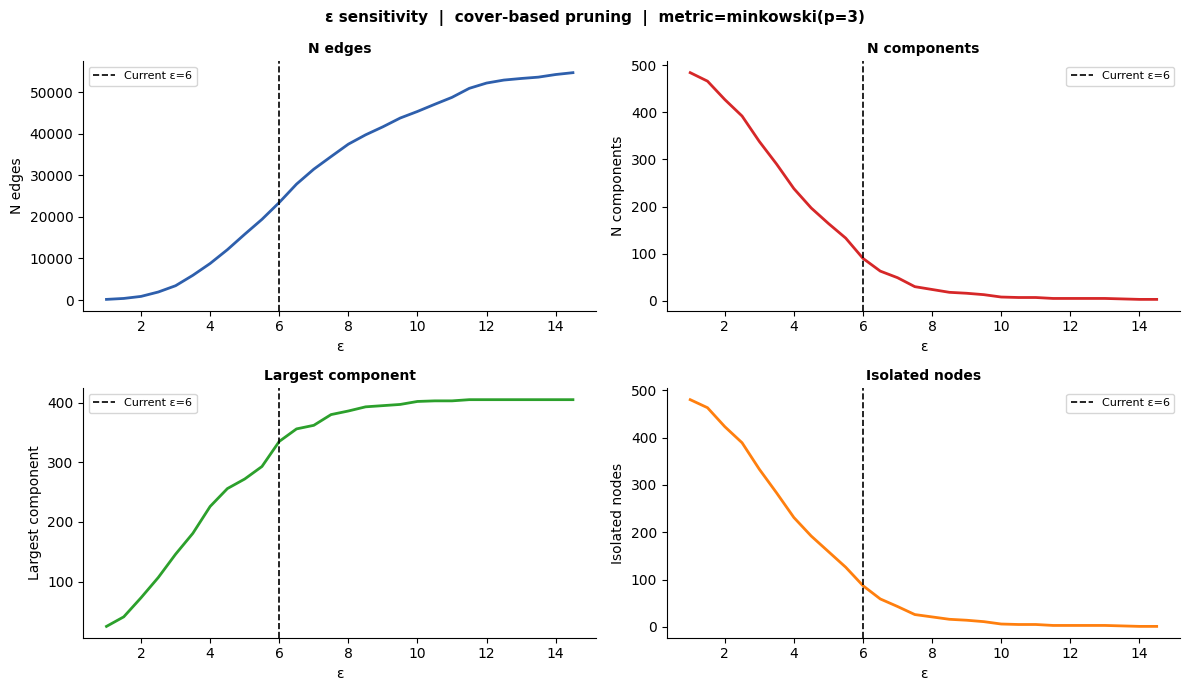


Selected ε stats:
 epsilon  n_edges  n_components  largest_comp  n_isolated  density_pct
     6.0    23461            90           335          87    17.864431


In [14]:
# ── Sweep ε and record graph statistics ───────────────────────────────────────
epsilon_range = np.arange(1.0, 15.0, 0.5)
sweep_records = []

for eps in epsilon_range:
    G_tmp = nx.Graph()
    G_tmp.add_nodes_from(range(len(df)))
    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            if D[i, j] <= eps:
                mi = set(memberships[i])
                mj = set(memberships[j])
                if mi and mj and mi & mj:
                    G_tmp.add_edge(i, j)
    comps = list(nx.connected_components(G_tmp))
    sweep_records.append({
        'epsilon'      : eps,
        'n_edges'      : G_tmp.number_of_edges(),
        'n_components' : len(comps),
        'largest_comp' : max(len(c) for c in comps) if comps else 0,
        'n_isolated'   : sum(1 for n in G_tmp.nodes if G_tmp.degree(n) == 0),
        'density_pct'  : G_tmp.number_of_edges() / (len(df) * (len(df)-1) / 2) * 100,
    })

sweep = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()
metrics = [
    ('n_edges',      'N edges',           '#2E5FAC'),
    ('n_components', 'N components',      '#d62728'),
    ('largest_comp', 'Largest component', '#2ca02c'),
    ('n_isolated',   'Isolated nodes',    '#ff7f0e'),
]
for ax, (col, label, color) in zip(axes, metrics):
    ax.plot(sweep['epsilon'], sweep[col], color=color, linewidth=2)
    ax.axvline(EPSILON, color='black', linestyle='--',
               linewidth=1.2, label=f'Current ε={EPSILON}')
    ax.set_xlabel('ε', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle(f'ε sensitivity  |  cover-based pruning  |  metric={metric_str}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('sow_epsilon_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSelected ε stats:")
row = sweep[np.isclose(sweep['epsilon'], EPSILON, atol=0.01)]
if not row.empty:
    print(row.to_string(index=False))